## 1 数据预处理

### 1.1 数据读取

In [1]:
import wordCutter as wc
import conf
import pandas as pd
from datetime import datetime

In [2]:
df = pd.read_csv('./Data/weibo_senti_100k.csv')

In [3]:
df

,label,review
0,1,﻿更博了，爆照了，帅的呀，就是越来越爱你！生快傻缺[爱你][爱你][爱你]
1,1,@张晓鹏jonathan 土耳其的事要认真对待[哈哈]，否则直接开除。@丁丁看世界 很是细心...
2,1,姑娘都羡慕你呢…还有招财猫高兴……//@爱在蔓延-JC:[哈哈]小学徒一枚，等着明天见您呢/...
3,1,美~~~~~[爱你]
4,1,梦想有多大，舞台就有多大![鼓掌]
...,...,...
119983,0,一公里不到，县医院那个天桥下右拐200米就到了！//@谢礼恒: 我靠。这个太霸道了！离224...
119984,0,今天真冷啊，难道又要穿棉袄了[晕]？今年的春天真的是百变莫测啊[抓狂]
119985,0,最近几天就没停止过！！！[伤心]
119986,0,//@毒药女流氓:[怒] 很惨!


### 1.2 缺失值处理

In [4]:
ndf=df.isnull()
print(True in ndf['label'].tolist())
print(True in ndf['review'].tolist())

False
False


未发现缺失值 无需处理

### 1.3 数据规约

In [5]:
sentences=df['review'].tolist()
labels=df['label'].tolist()
newsentences=[]
newlabels=[]
print('wordCutting')
print(datetime.now())
wordsList = wc.wordCutting(sentences)
print('wordCutting end')
print(datetime.now())
# 去除长度过长语料
for i in range(len(sentences)):
    if (len(wordsList[i]) > conf.wordCountThreshold):
        continue
    newsentences.append(sentences[i])
    newlabels.append(labels[i])

Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache


wordCutting
2023-11-19 21:09:02.376084


Loading model cost 0.823 seconds.
Prefix dict has been built successfully.


wordCutting end
2023-11-19 21:09:48.586610


In [6]:
print('original {}'.format(len(sentences)))
print('now {}'.format(len(newsentences)))

original 119988
now 108704


In [7]:
newdf=pd.DataFrame({'newsentences':newsentences,'newlabels':newlabels})
newdf

,newsentences,newlabels
0,﻿更博了，爆照了，帅的呀，就是越来越爱你！生快傻缺[爱你][爱你][爱你],1
1,@张晓鹏jonathan 土耳其的事要认真对待[哈哈]，否则直接开除。@丁丁看世界 很是细心...,1
2,姑娘都羡慕你呢…还有招财猫高兴……//@爱在蔓延-JC:[哈哈]小学徒一枚，等着明天见您呢/...,1
3,美~~~~~[爱你],1
4,梦想有多大，舞台就有多大![鼓掌],1
...,...,...
108699,周末在家被老婆要求给她拍照。[泪],0
108700,今天真冷啊，难道又要穿棉袄了[晕]？今年的春天真的是百变莫测啊[抓狂],0
108701,最近几天就没停止过！！！[伤心],0
108702,//@毒药女流氓:[怒] 很惨!,0


### 1.4 数据集分类

In [8]:
# 分类得到积极 消极语料
posSentences=[]
negSentences=[]
for i in range(len(newdf)):
    if newdf['newlabels'][i]==1:
        posSentences.append(newdf['newsentences'][i])
    if newdf['newlabels'][i]==0:
        negSentences.append(newdf['newsentences'][i])

In [9]:
# 长度
print('pos {} neg {}'.format(len(posSentences),len(negSentences)))

pos 54253 neg 54451


### 1.5 数据集描述

In [10]:
originPosCnt=0
originNegCnt=0
label=df['label'].tolist()
for i in label:
    if i == 1 :
        originPosCnt+=1
    if i== 0:
        originNegCnt+=1
print('pos {} neg {}'.format(originPosCnt,originNegCnt))

pos 59993 neg 59995


In [11]:
posCnt=0
negCnt=0
newlabel=newdf['newlabels'].tolist()
for i in newlabel:
    if i == 1 :
        posCnt+=1
    if i== 0:
        negCnt+=1
print('pos {} neg {}'.format(posCnt,negCnt))

pos 54253 neg 54451


## 2 模型评估

In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

### 2.1  数据导入

In [13]:
#0->RNNSpecial
totalLabs0=[]
preds1D0=[]
posProba0=[]
with open('./Data/results/totalLabs0.pkl','rb') as f:
    totalLabs0=pickle.load(f)
with open('./Data/results/preds1D0.pkl','rb') as f:
    preds1D0=pickle.load(f)
with open('./Data/results/posProba1D0.pkl','rb') as f:
    posProba0=pickle.load(f)

In [14]:
#1->CNNCommon
totalLabs1=[]
preds1D1=[]
posProba1=[]
with open('./Data/results/totalLabs1.pkl','rb') as f:
    totalLabs1=pickle.load(f)
with open('./Data/results/preds1D1.pkl','rb') as f:
    preds1D1=pickle.load(f)
with open('./Data/results/posProba1D1.pkl','rb') as f:
    posProba1=pickle.load(f)

In [15]:
#2->CNNSpecial
totalLabs2=[]
preds1D2=[]
posProba2=[]
with open('./Data/results/totalLabs2.pkl','rb') as f:
    totalLabs2=pickle.load(f)
with open('./Data/results/preds1D2.pkl','rb') as f:
    preds1D2=pickle.load(f)
with open('./Data/results/posProba1D2.pkl','rb') as f:
    posProba2=pickle.load(f)

In [16]:
#3->RNNCommon
totalLabs3=[]
preds1D3=[]
posProba3=[]
with open('./Data/results/totalLabs3.pkl','rb') as f:
    totalLabs3=pickle.load(f)
with open('./Data/results/preds1D3.pkl','rb') as f:
    preds1D3=pickle.load(f)
with open('./Data/results/posProba1D3.pkl','rb') as f:
    posProba3=pickle.load(f)

### 2.2 混淆矩阵及相关指标计算

In [17]:
def genData(totalLabs,preds1D):
    # 数据计算
    TP=0#真正类
    FP=0#假正类
    FN=0#真负类
    TN=0#假负类
    TOTAL=len(totalLabs)#数据总量
    for i in range(len(totalLabs)):
        if totalLabs[i]==1 and preds1D[i]==1:
            TP+=1
        if totalLabs[i]==0 and preds1D[i]==1:
            FP+=1
        if totalLabs[i]==0 and preds1D[i]==0:
            TN+=1
        if totalLabs[i]==1 and preds1D[i]==0:
            FN+=1
    cmatrix=[[TP,FP],[FN,TN]]#混淆矩阵
    cmatrix=[['','True','False']]+cmatrix
    cmatrix[1]=['Positive']+cmatrix[1]
    cmatrix[2]=['Negative']+cmatrix[2]
    cmdf=pd.DataFrame(cmatrix)
    accuracy=(TP+TN)/TOTAL#准确率
    precision=TP/(TP+FP)#查准率
    recall=TP/(TP+FN)#查全率
    f1=2*precision*recall/(precision+recall)#f1值
    return cmdf,accuracy,precision,recall,f1

In [18]:
def genCmatrix(totalLabs,preds1D):
    # 数据计算
    TP=0#真正类
    FP=0#假正类
    FN=0#真负类
    TN=0#假负类
    TOTAL=len(totalLabs)#数据总量
    for i in range(len(totalLabs)):
        if totalLabs[i]==1 and preds1D[i]==1:
            TP+=1
        if totalLabs[i]==0 and preds1D[i]==1:
            FP+=1
        if totalLabs[i]==0 and preds1D[i]==0:
            TN+=1
        if totalLabs[i]==1 and preds1D[i]==0:
            FN+=1
    cmatrix=[[TP,FP],[FN,TN]]#混淆矩阵
    return cmatrix

In [19]:
#0->RNNSpecial
cmdf0,accuracy0,precision0,recall0,f10=genData(totalLabs0,preds1D0)
cm0=genCmatrix(totalLabs0,preds1D0)

In [20]:
#1->CNNCommon
cmdf1,accuracy1,precision1,recall1,f11=genData(totalLabs1,preds1D1)
cm1=genCmatrix(totalLabs1,preds1D1)

In [21]:
#2->CNNSpecial
cmdf2,accuracy2,precision2,recall2,f12=genData(totalLabs2,preds1D2)
cm2=genCmatrix(totalLabs2,preds1D2)

In [22]:
#3->RNNCommon
cmdf3,accuracy3,precision3,recall3,f13=genData(totalLabs3,preds1D3)
cm3=genCmatrix(totalLabs3,preds1D3)

### 2.3 混淆矩阵可视化

/home/bugwaker/.local/lib/python3.6/site-packages/ipykernel_launcher.py:94: MatplotlibDeprecationWarning: 
The 'quality' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'quality': ...} instead. If any parameter follows 'quality', they should be passed as keyword, not positionally.


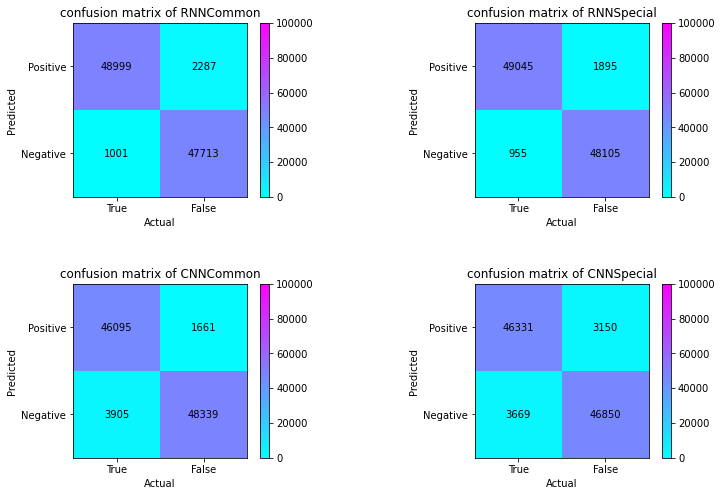

In [32]:
classes=[1,2]
fig = plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
arr3=np.array(cm3)
# 标题
plt.title('confusion matrix of RNNCommon')
# 绘制热力图
plt.imshow(arr3, cmap='cool')
# 设置坐标轴标签
plt.xlabel('Actual')
plt.ylabel('Predicted')
# 添加颜色条
plt.colorbar()
# 设置刻度
plt.clim(0,100000)
# 添加类别标签
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['True','False'])
plt.yticks(tick_marks, ['Positive','Negative'])
# 显示数值
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, arr3[i, j], ha='center', va='center', color='black')
# 显示图形

plt.subplot(2,2,2)
arr0=np.array(cm0)
# 标题
plt.title('confusion matrix of RNNSpecial')
# 绘制热力图
plt.imshow(arr0, cmap='cool')
# 设置坐标轴标签
plt.xlabel('Actual')
plt.ylabel('Predicted')
# 添加颜色条
plt.colorbar()
# 设置刻度
plt.clim(0,100000)
# 添加类别标签
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['True','False'])
plt.yticks(tick_marks, ['Positive','Negative'])
# 显示数值
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, arr0[i, j], ha='center', va='center', color='black')

plt.subplot(2,2,3)
arr1=np.array(cm1)
# 标题
plt.title('confusion matrix of CNNCommon')
# 绘制热力图
plt.imshow(arr1, cmap='cool')
# 设置坐标轴标签
plt.xlabel('Actual')
plt.ylabel('Predicted')
# 添加颜色条
plt.colorbar()
# 设置刻度
plt.clim(0,100000)
# 添加类别标签
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['True','False'])
plt.yticks(tick_marks, ['Positive','Negative'])
# 显示数值
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, arr1[i, j], ha='center', va='center', color='black')

plt.subplot(2,2,4)
arr2=np.array(cm2)
# 标题
plt.title('confusion matrix of CNNSpecial')
# 绘制热力图
plt.imshow(arr2, cmap='cool')
# 设置坐标轴标签
plt.xlabel('Actual')
plt.ylabel('Predicted')
# 添加颜色条
plt.colorbar()
# 设置刻度
plt.clim(0,100000)
# 添加类别标签
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['True','False'])
plt.yticks(tick_marks, ['Positive','Negative'])
# 显示数值
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, arr2[i, j], ha='center', va='center', color='black')
plt.subplots_adjust(hspace=0.5, wspace=0.5)
# 保存图形
plt.savefig('./../doc/imgs/cMatrix-higher-dpi.jpg',format='jpg',quality=100,dpi=1000)
# 显示图形
plt.show()

### 2.4 PR曲线 ROC曲线 AUC值

In [24]:
def getData(totalLabs,posProba1D):
    ps,rs,ts=metrics.precision_recall_curve(totalLabs,posProba1D)
    fprs,tprs,trs=metrics.roc_curve(totalLabs,posProba1D)
    auc=metrics.roc_auc_score(totalLabs,posProba1D)
    return ps,rs,fprs,tprs,auc

In [25]:
#0->RNNSpecial
ps0,rs0,fprs0,tprs0,auc0=getData(totalLabs0,posProba0)

In [26]:
#1->CNNCommon
ps1,rs1,fprs1,tprs1,auc1=getData(totalLabs1,posProba1)

In [27]:
#2->CNNSpecial
ps2,rs2,fprs2,tprs2,auc2=getData(totalLabs2,posProba2)

In [28]:
#3->RNNCommon
ps3,rs3,fprs3,tprs3,auc3=getData(totalLabs3,posProba3)

### 2.5 可视化 PR曲线 ROC曲线

/home/bugwaker/.local/lib/python3.6/site-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: 
The 'quality' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'quality': ...} instead. If any parameter follows 'quality', they should be passed as keyword, not positionally.
  # Remove the CWD from sys.path while we load stuff.


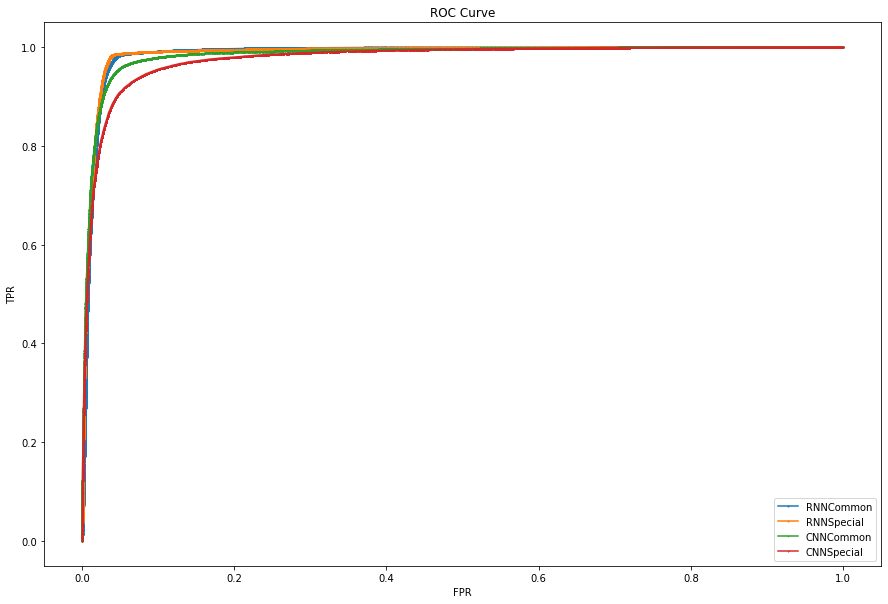

In [33]:
fig = plt.figure(figsize=(15, 10))
plt.plot(fprs3, tprs3, marker='o',markersize=1,label='RNNCommon')
plt.plot(fprs0, tprs0, marker='s',markersize=1,label='RNNSpecial')
plt.plot(fprs1, tprs1, marker='*',markersize=1,label='CNNCommon')
plt.plot(fprs2, tprs2, marker='+',markersize=1,label='CNNSpecial')
plt.legend()
plt.title('ROC Curve')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.savefig('../doc/imgs/ROC-higher-dpi.jpg',format='jpg',quality=100,dpi=1000)

/home/bugwaker/.local/lib/python3.6/site-packages/ipykernel_launcher.py:12: MatplotlibDeprecationWarning: 
The 'quality' parameter of print_jpg() was deprecated in Matplotlib 3.3 and will be removed two minor releases later. Use pil_kwargs={'quality': ...} instead. If any parameter follows 'quality', they should be passed as keyword, not positionally.
  if sys.path[0] == '':


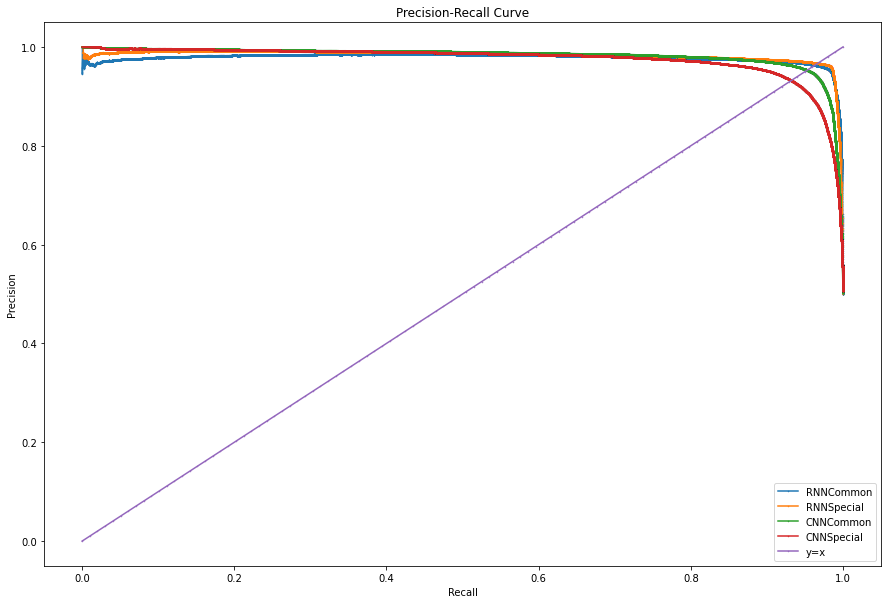

In [34]:
fig = plt.figure(figsize=(15, 10))
plt.plot(rs3, ps3, marker='.',markersize=1,label='RNNCommon')
plt.plot(rs0, ps0, marker='.',markersize=1,label='RNNSpecial')
plt.plot(rs1, ps1, marker='.',markersize=1,label='CNNCommon')
plt.plot(rs2, ps2, marker='.',markersize=1,label='CNNSpecial')
xy=np.linspace(start=0,stop=1,num=100).tolist()
plt.plot(xy, xy, marker='.',markersize=1,label='y=x')
plt.legend()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title('Precision-Recall Curve')
plt.savefig('../doc/imgs/PR-high-dpi.jpg',format='jpg',quality=100,dpi=500)

### 2.6 数值指标可视化

In [31]:
table=[
    ['model','accuracy','precision','recall','f1','auc'],
    ['RNNCommon',accuracy3,precision3,recall3,f13,auc3],
    ['RNNSpecial',accuracy0,precision0,recall0,f10,auc0],
    ['CNNCommon',accuracy1,precision1,recall1,f11,auc1],
    ['CNNSpecial',accuracy2,precision2,recall2,f12,auc2]
]
frame=pd.DataFrame(table)
frame.to_excel('../doc/docsAndCodes/relatedData.xlsx',index=False)
frame

,0,1,2,3,4,5
0,model,accuracy,precision,recall,f1,auc
1,RNNCommon,0.96712,0.955407,0.97998,0.967537,0.986539
2,RNNSpecial,0.9715,0.962799,0.9809,0.971765,0.988245
3,CNNCommon,0.94434,0.965219,0.9219,0.943062,0.984403
4,CNNSpecial,0.93181,0.936339,0.92662,0.931454,0.977172
